This notebook shows that we are getting different results for openvino format and keras format models

### Openvino models

## Requires Python>=3.9

In [1]:
# replace the filepath of requirements.txt  with your filepath
# ! pip install -r "requirements.txt"

In [2]:
# import pickle
import cv2
import numpy as np
from keras.models import load_model
import tensorflow as tf
import openvino as ov

sardine_freshness_ov_model = r"mobileapp models\sardine\sardine.xml"
mackerel_freshness_ov_model = r"mobileapp models\mackerel\mackerel.xml"
fish_model = r"mobileapp models\best_openvino_model"
cuts_model = r"mobileapp models\cut-seg_openvino_model"

target_size = (224, 224)
sardine_threshold = 0.5
mackerel_threshold = 0.26

# Initialize OpenVINO Core
core = ov.Core()

# Load Model
def load_model_ov(model_path):
    try:
        ov_model = core.read_model(model_path)
        ov_model.reshape({ov_model.inputs[0]: [1, 224, 224, 3]})
        model = ov.compile_model(ov_model)
    except:
        # Note: Ensure this path points to a keras model if using load_model,
        # otherwise loading .xml with keras might fail.
        model = load_model(model_path)
    return model

def inference_ov_async(infer_request, image):
    """
    Set the input tensor data using the provided image (converted to numpy),
    start asynchronous inference, wait for completion, and return the prediction.
    """
    input_tensor = infer_request.get_input_tensor()
    input_tensor.data[:] = image  # Convert TensorFlow tensor to numpy array
    infer_request.start_async()
    infer_request.wait()  # Wait for inference to complete
    return infer_request.get_output_tensor().data[0][0]

def inference_model(model, image):
    """
    Perform inference using asynchronous mode if OpenVINO is used; otherwise, fall back to synchronous inference.
    """
    output_layer_name = list(model.outputs[0].names)[0]
    try:
        # Use the asynchronous inference approach using the first request
        prediction = inference_ov_async(model.create_infer_request(), image)
        # print("With ASYNC inference") # Optional: Uncomment if you want to verify async usage
    except:
        print("Using synchronous inference")
        result = model(image)
        prediction = result[output_layer_name][0][0]
    return prediction

def process_image(image):
    """
    Resize and preprocess the input image.
    """
    resized_image = cv2.resize(image, target_size)
    processed_image = tf.keras.applications.densenet.preprocess_input(resized_image)
    processed_image = tf.expand_dims(processed_image, axis=0)
    return processed_image

def predict(image, threshold, model):
    """
    Process the input image, run inference, and return a label based on the threshold.
    """
    processed = process_image(image)
    pred = inference_model(model, processed)
    label = 'Good' if pred >= threshold else 'Bad'
    # print(f"Freshness Model Predicted --> Label: {label} , Confidence : {pred}")
    return label

In [3]:
import numpy as np
from PIL import Image
import cv2
import tensorflow as tf
from keras.models import load_model
import base64
from ultralytics import YOLO
import io

# Initialize YOLO models
try:
    yolo = YOLO(fish_model, task='segment')
    cut = YOLO(cuts_model, task='segment')

    # Warm-up routine
    dummy_image = np.zeros((640, 640, 3), dtype=np.uint8)
    yolo.predict(dummy_image, verbose=False)
    cut.predict(dummy_image, verbose=False)
    print("✅ YOLO detection models warm-up complete.")
except Exception as e:
    print(f"Error loading YOLO models from local path: {e}")


def extract_single_image_segment(img, mask_segment, shape, background='black'):
    """
    Extracts a specific segment from an image based on the provided mask.

    Args:
    - img: The original image.
    - mask_segment: The mask coordinates defining the segment to extract.
    - shape: The shape of the original image (height, width).
    - background: The background color for the extracted segment ('black' or 'white').

    Returns:
    - segment_image: The extracted image segment with the specified background.
    """
    height, width = shape[0], shape[1]
    segment = np.array(mask_segment, dtype=np.int32)
    segment = segment.reshape((-1, 2))
    mask = np.zeros((height, width), dtype=np.uint8)
    cv2.fillPoly(mask, [segment], 255)
    masked_img = cv2.bitwise_and(img, img, mask=mask)
    x, y, w, h = cv2.boundingRect(segment)
    segment_image = np.zeros((h, w, 3), dtype=np.uint8)
    segment_image[0:h, 0:w] = masked_img[y:y+h, x:x+w]

    if background.lower() == 'black':
        black_mask = np.all(segment_image == [0, 0, 0], axis=-1)
        segment_image[black_mask] = [0, 0, 0]  # Set background to black
    elif background.lower() == 'white':
        black_mask = np.all(segment_image == [0, 0, 0], axis=-1)
        segment_image[black_mask] = [255, 255, 255]  # Set background to white
    else:
        raise ValueError("Invalid background color. Use 'black' or 'white'.")

    return segment_image

def process_image2(image, size=(640, 640)): # for eye model
    """
    Pre-process the image for the damage detection model.
    Resizes and pads the image to the specified size while maintaining aspect ratio.
    """
    h, w = image.shape[:2]
    aspect_ratio = w / h
    if aspect_ratio > 1:
        new_w = size[0]
        new_h = int(new_w / aspect_ratio)
    else:
        new_h = size[1]
        new_w = int(new_h * aspect_ratio)

    resized_image = cv2.resize(image, (new_w, new_h))

    pad_h = (size[1] - new_h) // 2
    pad_w = (size[0] - new_w) // 2
    padded_image = cv2.copyMakeBorder(
        resized_image, pad_h, pad_h, pad_w, pad_w, cv2.BORDER_CONSTANT, value=(255, 255, 255)
    )
    padded_image = cv2.resize(padded_image, (640,640))
    return np.asarray(padded_image)


def is_cut(image, conf=0.5):
    """
    Detect if the fish in the image has cuts or damages using the YOLO model.

    Args:
    - image: The input image.
    - conf: Confidence threshold for detection.

    Returns:
    - True if damage is detected, False otherwise.
    """
    img = image[:,:,::-1]
    res = cut.predict(img, conf=conf)
    if len(res[0].boxes.xyxy) == 0:
        return False, 0
    else:
        return True, res[0].boxes.conf[0].item()

def return_mask(image, masks, labels, boxes):
    """
    Draw masks and labels on the image based on detection results.

    Args:
    - image: The original image.
    - masks: List of masks for detected objects.
    - labels: List of labels corresponding to detected objects.
    - boxes: List of bounding boxes for detected objects.

    Returns:
    - image_with_masks: The image with drawn masks and labels.
    """
    # Ensure the image is writable by creating a copy
    writable_image = np.copy(image)

    mask_image = np.zeros_like(writable_image)

    height, width, _ = writable_image.shape

    for mask, label, box in zip(masks, labels, boxes):
        xmin, ymin, xmax, ymax = list(map(int, box))

        # Calculate the thickness and text size based on image dimensions
        thickness = max(int(min(height, width) / 200), 1)
        text_size = max(int(min(height, width) / 800), 1)

        if 'good' in label.lower():
            color = (0, 255, 0)  # Green mask
        elif 'ok' in label.lower():
            color = (255, 255, 0)  # Yellow mask
        else:
            color = (255, 0, 0)  # Red mask

        mask_coords = np.array(mask, dtype=np.int32)
        cv2.fillPoly(mask_image, [mask_coords], color)
        cv2.rectangle(writable_image, (xmin, ymin), (xmax, ymax), color, thickness)
        cv2.putText(writable_image, label, (xmin, ymin - 10), cv2.FONT_HERSHEY_SIMPLEX, text_size, color, thickness)

    alpha = 0.2  # Transparency level for the mask
    image_with_masks = cv2.addWeighted(writable_image, 1 - alpha, mask_image, alpha, 0)
    image_with_masks = cv2.cvtColor(image_with_masks, cv2.COLOR_BGR2RGB)
    return image_with_masks


def freshness_prediction(image, w_mask_image, b_mask_image, fish, box):
    """
    Predict the freshness of a fish based on its appearance and characteristics.

    Args:
    - image: Original image containing the fish.
    - w_mask_image: Image segment with white background.
    - b_mask_image: Image segment with black background.
    - fish: Species of the fish.
    - box: Bounding box coordinates of the fish.

    Returns:
    - label: Freshness label ('Good' or 'Bad').
    - reason: Reason for the freshness label, if any.
    """
    # Check the species of the fish and perform freshness prediction accordingly
    if fish.lower() == 'sardine':
        damage, conf = is_cut(process_image2(w_mask_image), conf=0.85)
        if damage:
            return 'Bad', f'Damaged-{conf}'
        else:
            # Predict freshness based on Species-specific model
            pred = predict(b_mask_image, sardine_threshold, model)
            if pred == 'Bad':
                return pred, 'Softness'
            else:
                return pred, None
    elif fish.lower() == 'mackerel':
        damage, conf = is_cut(process_image2(image=w_mask_image), conf=0.85)
        if damage:
            return 'Bad', f'Damaged-{conf}'
        else:
            # Predict freshness based on Species-specific model
            pred = predict(b_mask_image, mackerel_threshold, model)
            if pred == 'Bad':
                return pred, 'Softness'
            else:
                return pred, None
    else:
        damage, conf = is_cut(process_image2(image=w_mask_image), conf=0.65)
        if damage:
            return 'Bad', f'Damaged-{conf}'
        else:
            return 'Good', None

def final_prediction(image, species, model):
    """
    Perform final prediction on the given image for a specific species using a specified model.

    Args:
    - image: Image file path or image data (numpy array).
    - species: Species label for classification.
    - model: Model name ('fish' or 'prawn').

    Returns:
    - result: A dictionary containing the prediction results.
    """
    result = dict()
    top3 = []

    # Open image and convert it to numpy array
    try:
        img = Image.open(image)
        if img.mode != 'RGB':
            img = img.convert('RGB')
        img_byte_arr = io.BytesIO()
        img.save(img_byte_arr, format=img.format)
        img_byte_arr = img_byte_arr.getvalue()
        img_from_bytes = Image.open(io.BytesIO(img_byte_arr))
        image = np.asarray(img_from_bytes)
    except Exception as e:
        # return None
        return {
                "fishes-detected": 'img read error',
                "confidence": 0,
                "good-fishes": 0,
                "bad-fishes": 0,
                "reasons": [],
                "image-encode": None,
                "classification": "False",
                "species": species,
                "first3": []
            }

    shape = image.shape

    # Perform object detection based on model
    if model.lower() == 'fish':
        pred = yolo.predict(image[:, :, ::-1], conf=0.75)
        if len(pred[0].boxes.xyxy) == 0 :
            return {
                "fishes-detected": 0,
                "confidence": 0,
                "good-fishes": 0,
                "bad-fishes": 0,
                "reasons": [],
                "image-encode": None,
                "classification": "False",
                "species": species,
                "first3": []
            }

    ## uncomment these for final     
    # # Extract bounding boxes and masks
    # boxes = pred[0].boxes.xyxy
    # masks = pred[0].masks.xy
    # filtered_boxes = sorted(boxes, key=lambda bbox: bbox[0])
    # sorted_masks = [masks[i] for i in sorted(range(len(masks)), key=lambda x: boxes[x][0])]

    # --------------- for debugging purposes ---------------
    # Convert tensors to numpy
    boxes_np = pred[0].boxes.xyxy.cpu().numpy()
    conf_np = pred[0].boxes.conf.cpu().numpy()
    masks = pred[0].masks.xy

    # Get sorted indices based on xmin (left-most coordinate)
    sorted_indices = np.argsort(boxes_np[:, 0])

    # Apply sorting consistently
    filtered_boxes = boxes_np[sorted_indices]
    sorted_masks = [masks[i] for i in sorted_indices]
    sorted_conf = conf_np[sorted_indices]


    new_labels = []
    reasons = []
    i = 0

    # Iterate over each detected box and mask
    for box, mask in zip(filtered_boxes, sorted_masks):
        i += 1
        xmin, ymin, xmax, ymax = list(map(int, box))
        extracted_image = image[ymin:ymax, xmin:xmax]

        # Perform freshness prediction
        w_mask_image = extract_single_image_segment(image, mask, shape=shape, background='white')
        b_mask_image = extract_single_image_segment(image, mask, shape=shape, background='black')
        L, R = freshness_prediction(image, w_mask_image, b_mask_image, species, box)

        # Construct label for the prediction
        v = str(i) + '-' + str(L)
        if R is not None:
            v += '-' + str(R)
        reasons.append(R)
        new_labels.append(v)

    # Generate output image with labels
    output_image = return_mask(image, sorted_masks, new_labels, filtered_boxes)
    _, image_bytes = cv2.imencode('.jpg', output_image)
    encoded_string = base64.b64encode(image_bytes).decode('utf-8')

    # Count good and bad predictions
    good = 0
    bad = 0
    for i in range(len(new_labels)):
        fresh = new_labels[i].split('-')[1]
        top3.append(fresh)
        if fresh.lower() == 'good':
            good += 1
        else:
            bad += 1

    # Construct result dictionary
    result['fishes-detected'] = good + bad
    result['confidence'] = sorted_conf if len(sorted_conf) > 0 else 0
    result['good-fishes'] = good
    result['bad-fishes'] = bad
    result['reasons'] = reasons
    result['image-encode'] = encoded_string
    result['classification'] = 'True'
    result['species'] = species
    result['first3'] = top3
    return result

Loading mobileapp models\best_openvino_model for OpenVINO inference...
Loading mobileapp models\cut-seg_openvino_model for OpenVINO inference...


✅ YOLO detection models warm-up complete.


In [ ]:
from tqdm import tqdm
import os
import pandas as pd
from pathlib import Path
from typing import List, Dict, Optional

def build_freshness_evaluation_df(
    root_dir: str,
    species: str = "sardine",
    model_type: str = "fish",
    valid_exts: Optional[List[str]] = None
) -> pd.DataFrame:
    """
    Run batch inference on a folder of images and return a structured DataFrame
    containing per-fish predictions.

    Progress bar shows evaluation status across images.

    Parameters
    ----------
    root_dir : str
        Path to the root input directory (e.g., "input/").
    species : str, default="sardine"
        Species name passed to the freshness pipeline.
    model_type : str, default="fish"
        Model type passed to `final_prediction`.
    valid_exts : list[str], optional
        Allowed image extensions.

    Returns
    -------
    pd.DataFrame
        Fish-level prediction DataFrame.
    """

    if valid_exts is None:
        valid_exts = [".jpg", ".jpeg", ".png", ".bmp"]

    rows: List[Dict] = []
    root_dir = Path(root_dir)

    if not root_dir.exists():
        raise FileNotFoundError(f"Input directory does not exist: {root_dir}")

    # Collect all valid image files first (for tqdm total)
    image_files = [
        p for p in root_dir.rglob("*")
        if p.suffix.lower() in valid_exts
        and p.parent.name.lower() in {"good", "bad"}
    ]

    for image_path in tqdm(
        image_files,
        desc="Evaluating images",
        unit="image"
    ):
        actual_class = image_path.parent.name.lower()

        try:
            result = final_prediction(
                image=str(image_path),
                species=species,
                model=model_type
            )
        except Exception:
            result = {
                "fishes-detected": 'exception',
                "confidence": 0,
                "good-fishes": 0,
                "bad-fishes": 0,
                "reasons": [],
                "image-encode": None,
                "classification": "False",
                "species": species,
                "first3": []
            }
            
            fish_detected = result.get("fishes-detected", 0)
            predictions = result.get("first3", [])
            reasons = result.get("reasons", [])
            confidences = result.get("confidence", [])
            
            base_name = image_path.name
            filename_id = base_name.split("_")[4]
            
            rows.append({
                "date": base_name.split("_")[0],
                "filename": base_name,
                "filename_id": filename_id,
                "fish_detected": fish_detected,
                "confidence": confidences,
                "actual_class": actual_class.capitalize(),
                "predicted_class": "no prediction",
                "reason": "reason not available"
            }) 
            
            continue

        if result is None:
            result = {
                "fishes-detected": 'result is None',
                "confidence": 0,
                "good-fishes": 0,
                "bad-fishes": 0,
                "reasons": [],
                "image-encode": None,
                "classification": "False",
                "species": species,
                "first3": []
            }
            
            fish_detected = result.get("fishes-detected", 0)
            predictions = result.get("first3", [])
            reasons = result.get("reasons", [])
            confidences = result.get("confidence", [])
            
            base_name = image_path.name
            filename_id = base_name.split("_")[4]
            
            rows.append({
                "date": base_name.split("_")[0],
                "filename": base_name,
                "filename_id": filename_id,
                "fish_detected": fish_detected,
                "confidence": confidences,
                "actual_class": actual_class.capitalize(),
                "predicted_class": "no prediction",
                "reason": "reason not available"
            })                 
            continue
        
        fish_detected = result.get("fishes-detected", 0)
        predictions = result.get("first3", [])
        reasons = result.get("reasons", [])
        confidences = result.get("confidence", [])
        
        base_name = image_path.name
        filename_id = base_name.split("_")[4]

        for idx, pred_class in enumerate(predictions, start=1):
            fish_filename = f"{filename_id}_({idx})"

            reason = reasons[idx - 1] if idx - 1 < len(reasons) else None

            rows.append({
                "date": base_name.split("_")[0],
                "filename": base_name,
                "filename_id": fish_filename,
                "fish_detected": fish_detected,
                "confidence": confidences,
                "actual_class": actual_class.capitalize(),
                "predicted_class": pred_class.capitalize(),
                "reason": reason
            })

    return pd.DataFrame(
        rows,
        columns=[
            "date",
            "filename",
            "filename_id",
            "fish_detected",
            "confidence",
            "actual_class",
            "predicted_class",
            "reason"
        ]
    )

In [5]:
model = load_model_ov(sardine_freshness_ov_model)
# model = load_model_ov(mackerel_freshness_ov_model)

In [6]:
# Warm-up routine
dummy_image = np.zeros((1, 224, 224, 3), dtype=np.float32)
try:
    inference_model(model, dummy_image)
    print("✅ Freshness model warm-up complete.")
except Exception as e:
    print(f"Error during warm-up: {e}")

✅ Freshness model warm-up complete.


In [7]:
df = build_freshness_evaluation_df(
    root_dir=r"Sardine Recent App Testing Input Data",
    species="sardine",
    model_type="fish"
)

# df = build_freshness_evaluation_df(
#     root_dir=r"Mackerel Recent App Testing Input Data",
#     species="mackerel",
#     model_type="fish"
# )

df.head()

Evaluating images: 100%|██████████| 653/653 [20:25<00:00,  1.88s/image]


,date,filename,filename_id,fish_detected,confidence,actual_class,predicted_class,reason
0,2024-12-03,2024-12-03_10_14_57_(17680)_sardine_input.jpeg,(17680)_(1),2,"[0.92225045, 0.93380445]",Bad,Good,None
1,2024-12-03,2024-12-03_10_14_57_(17680)_sardine_input.jpeg,(17680)_(2),2,"[0.92225045, 0.93380445]",Bad,Bad,Softness
2,2024-12-03,2024-12-03_10_15_09_(17681)_sardine_input.jpeg,(17681)_(1),2,"[0.941136, 0.94819975]",Bad,Bad,Softness
3,2024-12-03,2024-12-03_10_15_09_(17681)_sardine_input.jpeg,(17681)_(2),2,"[0.941136, 0.94819975]",Bad,Bad,Softness
4,2024-12-03,2024-12-03_10_15_20_(17682)_sardine_input.jpeg,(17682)_(1),2,"[0.9205676, 0.9072604]",Bad,Bad,Softness


In [8]:
df.to_csv(r"prod_flow_sardine_results.csv", index=False)

In [9]:
"""
evaluation_metrics.py

Utilities for computing and visualizing classification metrics
for fish freshness evaluation.

Author: Your Name
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report


def plot_confusion_matrix(
    y_true,
    y_pred,
    labels=("Good", "Bad"),
    normalize=False,
    title="Confusion Matrix",
    cmap=plt.cm.Blues
):
    """
    Plot a confusion matrix with optional normalization.

    Parameters
    ----------
    y_true : array-like
        Ground truth labels.
    y_pred : array-like
        Predicted labels.
    labels : tuple, default=("Good", "Bad")
        Label order for the confusion matrix.
    normalize : bool, default=False
        If True, normalize confusion matrix by row (true labels).
    title : str
        Plot title.
    cmap : matplotlib colormap
        Colormap used for plotting.
    """

    cm = confusion_matrix(y_true, y_pred, labels=labels)

    if normalize:
        cm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
        cm = np.nan_to_num(cm)
        title += " (Normalized)"

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, interpolation="nearest", cmap=cmap)
    ax.figure.colorbar(im, ax=ax)

    ax.set(
        xticks=np.arange(len(labels)),
        yticks=np.arange(len(labels)),
        xticklabels=labels,
        yticklabels=labels,
        ylabel="Actual Label",
        xlabel="Predicted Label",
        title=title
    )

    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    fmt = ".2f" if normalize else "d"
    thresh = cm.max() / 2.0

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j,
                i,
                format(cm[i, j], fmt),
                ha="center",
                va="center",
                color="white" if cm[i, j] > thresh else "black"
            )

    fig.tight_layout()
    plt.show()


def print_classification_metrics(
    df,
    actual_col="actual_class",
    pred_col="predicted_class",
    labels=("Good", "Bad")
):
    """
    Print classification metrics using sklearn.

    Parameters
    ----------
    df : pd.DataFrame
        Evaluation DataFrame.
    actual_col : str
        Column name containing ground truth labels.
    pred_col : str
        Column name containing predicted labels.
    labels : tuple
        Class label order.
    """

    y_true = df[actual_col]
    y_pred = df[pred_col]

    print("\n📊 Classification Report")
    print("-" * 60)
    print(
        classification_report(
            y_true,
            y_pred,
            labels=list(labels),
            target_names=list(labels),
            digits=2
        )
    )

    print("\n📊 Confusion Matrix")
    print("-" * 60)
    plot_confusion_matrix(y_true, y_pred, labels=labels)


In [10]:
df = pd.read_csv(r"prod_flow_sardine_results.csv")


📊 Classification Report
------------------------------------------------------------
              precision    recall  f1-score   support

        Good       0.84      0.73      0.78       833
         Bad       0.61      0.76      0.68       474

    accuracy                           0.74      1307
   macro avg       0.73      0.74      0.73      1307
weighted avg       0.76      0.74      0.74      1307


📊 Confusion Matrix
------------------------------------------------------------


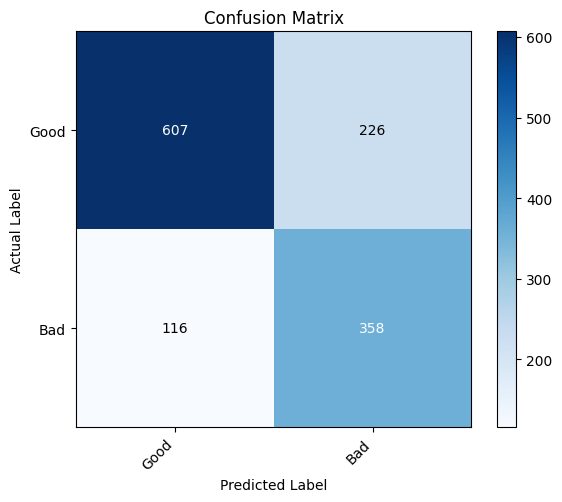

In [11]:
# Print metrics
print_classification_metrics(df)

In [12]:
df.head()

,date,filename,filename_id,fish_detected,confidence,actual_class,predicted_class,reason
0,2024-12-03,2024-12-03_10_14_57_(17680)_sardine_input.jpeg,(17680)_(1),2,[ 0.92225 0.9338],Bad,Good,NaN
1,2024-12-03,2024-12-03_10_14_57_(17680)_sardine_input.jpeg,(17680)_(2),2,[ 0.92225 0.9338],Bad,Bad,Softness
2,2024-12-03,2024-12-03_10_15_09_(17681)_sardine_input.jpeg,(17681)_(1),2,[ 0.94114 0.9482],Bad,Bad,Softness
3,2024-12-03,2024-12-03_10_15_09_(17681)_sardine_input.jpeg,(17681)_(2),2,[ 0.94114 0.9482],Bad,Bad,Softness
4,2024-12-03,2024-12-03_10_15_20_(17682)_sardine_input.jpeg,(17682)_(1),2,[ 0.92057 0.90726],Bad,Bad,Softness


In [14]:
df['reason'].unique()

array([nan, 'Softness', 'Damaged-0.8636679649353027',
       'Damaged-0.8672873973846436', 'Damaged-0.8651271462440491',
       'Damaged-0.9036572575569153', 'Damaged-0.86943519115448',
       'Damaged-0.8751546144485474', 'Damaged-0.8732501268386841',
       'Damaged-0.8579312562942505', 'Damaged-0.8750800490379333',
       'Damaged-0.8941131234169006', 'Damaged-0.8529447317123413',
       'Damaged-0.8846579194068909', 'Damaged-0.8753101825714111',
       'Damaged-0.8590242862701416', 'Damaged-0.9032931327819824',
       'Damaged-0.9052026271820068'], dtype=object)

In [53]:
import pandas as pd
df = pd.read_csv(r"C:\Users\sowmy\Downloads\sardine-mackerel white paper replication\prod_flow_mackerel_results.csv")
df.head()

,date,filename,filename_id,fish_detected,confidence,actual_class,predicted_class,reason
0,2025-01-02,2025-01-02_10_38_59_(18405)_mackerel_input.jpeg,(18405)_(1),2,[ 0.95001 0.93806],Good,Good,0.98889285
1,2025-01-02,2025-01-02_10_38_59_(18405)_mackerel_input.jpeg,(18405)_(2),2,[ 0.95001 0.93806],Good,Good,0.9861946
2,2025-01-02,2025-01-02_10_39_19_(18406)_mackerel_input.jpeg,(18406)_(1),2,[ 0.92736 0.94377],Good,Good,0.98477286
3,2025-01-02,2025-01-02_10_39_19_(18406)_mackerel_input.jpeg,(18406)_(2),2,[ 0.92736 0.94377],Good,Bad,Damaged-0.8853150606155396
4,2025-01-02,2025-01-02_10_39_28_(18407)_mackerel_input.jpeg,(18407)_(1),2,[ 0.95069 0.9436],Good,Good,0.9796057


In [54]:
ndf = pd.read_csv(r"C:\Users\sowmy\Downloads\codespaces-practice\prod_flow_mackerel_results.csv")
ndf.head()

,date,filename,filename_id,fish_detected,confidence,actual_class,predicted_class,reason
0,2025-01-07,2025-01-07_11_14_10_(18642)_mackerel_input.jpeg,(18642)_(1),2,[ 0.95411 0.95154],Bad,Good,0.2868092
1,2025-01-07,2025-01-07_11_14_10_(18642)_mackerel_input.jpeg,(18642)_(2),2,[ 0.95411 0.95154],Bad,Good,0.96386766
2,2025-01-07,2025-01-07_11_13_58_(18640)_mackerel_input.jpeg,(18640)_(1),2,[ 0.94833 0.953],Good,Good,0.96897733
3,2025-01-07,2025-01-07_11_13_58_(18640)_mackerel_input.jpeg,(18640)_(2),2,[ 0.94833 0.953],Good,Good,0.96888095
4,2025-01-07,2025-01-07_11_09_15_(18613)_mackerel_input.jpeg,(18613)_(1),2,[ 0.9507 0.95924],Good,Good,0.9764097


In [55]:
# check if the actual_class and predicted_class columns are same for the common filename_ids in both dfs 
mismatches = []
common_ids = ndf[ndf['filename_id'].isin(df['filename_id'].unique())]['filename_id'].unique()
c1 = lambda filename_id: df[df['filename_id']==filename_id]['predicted_class'].values[0] != ndf[ndf['filename_id']==filename_id]['predicted_class'].values[0]
c2 = lambda filename_id: df[df['filename_id']==filename_id]['actual_class'].values[0] != ndf[ndf['filename_id']==filename_id]['actual_class'].values[0]

# Update c3 to handle NaNs
def check_reason_mismatch(fid):
    val_df = df.loc[df['filename_id']==fid, 'reason'].values[0]
    val_ndf = ndf.loc[ndf['filename_id']==fid, 'reason'].values[0]
    
    # If both are NaN, they are NOT a mismatch -> return False
    if pd.isna(val_df) and pd.isna(val_ndf):
        return False
    
    # Otherwise, check standard inequality
    return val_df != val_ndf

c3 = lambda filename_id: check_reason_mismatch(filename_id)
for filename_id in common_ids:
    if c1(filename_id) or c2(filename_id):
        mismatches.append(filename_id)
        
data = []
for mismatch in sorted(mismatches):
    data.append({
        'filename_id': mismatch,
        'df_pred': df.loc[df['filename_id'] == mismatch, 'predicted_class'].iloc[0],
        'ndf_pred': ndf.loc[ndf['filename_id'] == mismatch, 'predicted_class'].iloc[0],
        'df_act': df.loc[df['filename_id'] == mismatch, 'actual_class'].iloc[0],
        'ndf_act': ndf.loc[ndf['filename_id'] == mismatch, 'actual_class'].iloc[0],
        'df_reason': df.loc[df['filename_id'] == mismatch, 'reason'].iloc[0],
        'ndf_reason': ndf.loc[ndf['filename_id'] == mismatch, 'reason'].iloc[0],
        'filename': df.loc[df['filename_id'] == mismatch, 'filename'].iloc[0],
        'df_fish_detected': df.loc[df['filename_id'] == mismatch, 'fish_detected'].iloc[0],
        'ndf_fish_detected': ndf.loc[ndf['filename_id'] == mismatch, 'fish_detected'].iloc[0],
        'df_confidence': df.loc[df['filename_id'] == mismatch, 'confidence'].iloc[0],
        'ndf_confidence': ndf.loc[ndf['filename_id'] == mismatch, 'confidence'].iloc[0]
    })

result_df = pd.DataFrame(data)
result_df

,filename_id,df_pred,ndf_pred,df_act,ndf_act,df_reason,ndf_reason,filename,df_fish_detected,ndf_fish_detected,df_confidence,ndf_confidence
0,(19196)_(1),Bad,Good,Bad,Bad,Softness-0.256103515625,0.26013428,2025-01-28_10_49_54_(19196)_mackerel_input.jpeg,2,2,[ 0.94681 0.9503],[ 0.94681 0.9503]


In [56]:
result_df.to_csv(r"mackerel mismatches.csv", index=False)

In [12]:
import pandas as pd
df = pd.read_csv(r"C:\Users\sowmy\Downloads\sardine-mackerel white paper replication\prod_flow_sardine_results.csv")
df = df[df['date']=='2024-12-03']
df.head()

,date,filename,filename_id,fish_detected,confidence,actual_class,predicted_class,reason
0,2024-12-03,2024-12-03_10_14_57_(17680)_sardine_input.jpeg,(17680)_(1),2,[ 0.92225 0.9338],Bad,Good,0.5565667
1,2024-12-03,2024-12-03_10_14_57_(17680)_sardine_input.jpeg,(17680)_(2),2,[ 0.92225 0.9338],Bad,Bad,Softness-0.01875869557261467
2,2024-12-03,2024-12-03_10_15_09_(17681)_sardine_input.jpeg,(17681)_(1),2,[ 0.94114 0.9482],Bad,Bad,Softness-0.05076461285352707
3,2024-12-03,2024-12-03_10_15_09_(17681)_sardine_input.jpeg,(17681)_(2),2,[ 0.94114 0.9482],Bad,Bad,Softness-0.44856420159339905
4,2024-12-03,2024-12-03_10_15_20_(17682)_sardine_input.jpeg,(17682)_(1),2,[ 0.92057 0.90726],Bad,Bad,Softness-0.14384502172470093


In [13]:
ndf = pd.read_csv(r"C:\Users\sowmy\Downloads\prod_flow_sardine_results (4).csv")
ndf.head()

,date,filename,filename_id,fish_detected,confidence,actual_class,predicted_class,reason
0,2024-12-03,2024-12-03_10_19_29_(17702)_sardine_input.jpeg,(17702),0,0,Bad,no fish detected,yolo_zero_detection
1,2024-12-03,2024-12-03_10_15_45_(17684)_sardine_input.jpeg,(17684),0,0,Bad,no fish detected,yolo_zero_detection
2,2024-12-03,2024-12-03_10_16_10_(17686)_sardine_input.jpeg,(17686),0,0,Bad,no fish detected,yolo_zero_detection
3,2024-12-03,2024-12-03_10_15_20_(17682)_sardine_input.jpeg,(17682),0,0,Bad,no fish detected,yolo_zero_detection
4,2024-12-03,2024-12-03_10_18_22_(17697)_sardine_input.jpeg,(17697),0,0,Bad,no fish detected,yolo_zero_detection


In [18]:
df[df['filename_id'].str.contains("17702")]

,date,filename,filename_id,fish_detected,confidence,actual_class,predicted_class,reason
44,2024-12-03,2024-12-03_10_19_29_(17702)_sardine_input.jpeg,(17702)_(1),2,[ 0.92091 0.93115],Bad,Bad,Softness-0.01666259765625
45,2024-12-03,2024-12-03_10_19_29_(17702)_sardine_input.jpeg,(17702)_(2),2,[ 0.92091 0.93115],Bad,Bad,Softness-0.2108154296875


In [19]:
ndf[ndf['filename_id'].str.contains("17702")]

,date,filename,filename_id,fish_detected,confidence,actual_class,predicted_class,reason
0,2024-12-03,2024-12-03_10_19_29_(17702)_sardine_input.jpeg,(17702),0,0,Bad,no fish detected,yolo_zero_detection


In [14]:
ndf['fish_detected'].unique(), ndf['reason'].unique()

(array([0], dtype=int64), array(['yolo_zero_detection'], dtype=object))

In [15]:
df.shape, ndf.shape

((62, 8), (31, 8))

In [10]:
df['date'].nunique(), ndf['date'].nunique()

(1, 1)


0: 480x640 2 fishs, 1176.9ms
Speed: 11.9ms preprocess, 1176.9ms inference, 29.2ms postprocess per image at shape (1, 3, 480, 640)


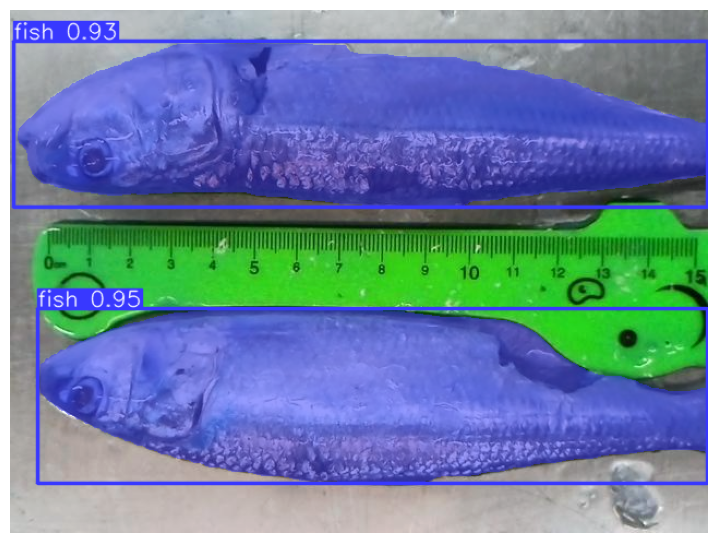

In [1]:
# import libraries for testing
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from ultralytics import YOLO
import io

image = r"C:\Users\sowmy\Downloads\sardine-mackerel white paper replication\Sardine Recent App Testing Input Data\2024-12-03_10_19_29_(17702)_sardine_input.jpeg"
img = Image.open(image) 
if img.mode != 'RGB':
    img = img.convert('RGB')
img_byte_arr = io.BytesIO()
img.save(img_byte_arr, format=img.format)
img_byte_arr = img_byte_arr.getvalue()
img_from_bytes = Image.open(io.BytesIO(img_byte_arr))
image = np.asarray(img_from_bytes)

# fish_model = r"mobileapp models/best_openvino_model"
fish_model = r"C:\Users\sowmy\Downloads\sardine-repro(old)\mobile app models non ov\fish (2).pt"
yolo = YOLO(fish_model, task='segment')
pred = yolo.predict(image[:, :, ::-1], conf=0.75)
for p in pred:
    plt.figure(figsize=(9, 9))
    plt.imshow(p.plot())
    plt.axis('off')

Loading mobileapp models\best_openvino_model for OpenVINO inference...

0: 640x640 2 fishs, 647.7ms
Speed: 3.0ms preprocess, 647.7ms inference, 9.0ms postprocess per image at shape (1, 3, 640, 640)


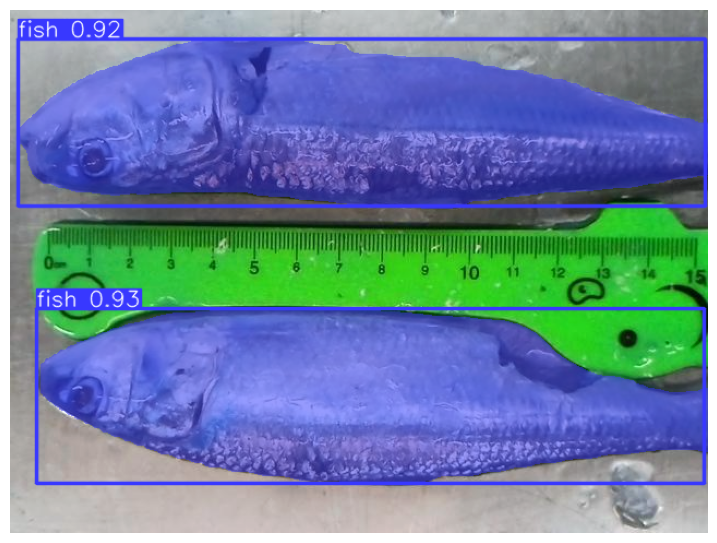

In [3]:
fish_model = r"mobileapp models/best_openvino_model"
# fish_model = r"C:\Users\sowmy\Downloads\sardine-repro(old)\mobile app models non ov\fish (2).pt"
yolo = YOLO(fish_model, task='segment')
pred = yolo.predict(image[:, :, ::-1], conf=0.75)
for p in pred:
    plt.figure(figsize=(9, 9))
    plt.imshow(p.plot())
    plt.axis('off')

Loading C:\Users\sowmy\Downloads\sardine-repro(old)\mobile app models ov converted\fish (2)_openvino_model for OpenVINO inference...

0: 640x640 2 fishs, 606.6ms
Speed: 6.4ms preprocess, 606.6ms inference, 4.0ms postprocess per image at shape (1, 3, 640, 640)


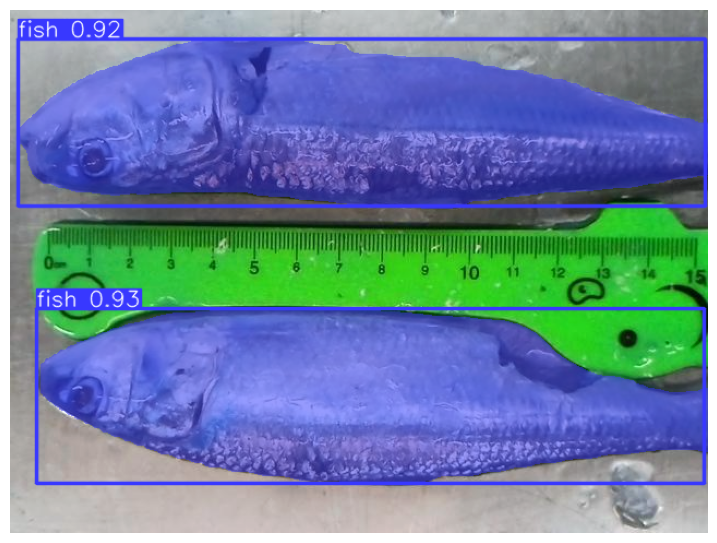

In [4]:
fish_model = r"C:\Users\sowmy\Downloads\sardine-repro(old)\mobile app models ov converted\fish (2)_openvino_model"
yolo = YOLO(fish_model, task='segment')
pred = yolo.predict(image[:, :, ::-1], conf=0.75)
for p in pred:
    plt.figure(figsize=(9, 9))
    plt.imshow(p.plot())
    plt.axis('off')

In [24]:
import ultralytics, torch, cv2, numpy as np, platform
print("OS:", platform.platform())
print("ultralytics:", ultralytics.__version__)
print("torch:", torch.__version__)
print("opencv:", cv2.__version__)
print("mps available:", torch.backends.mps.is_available() if hasattr(torch.backends, "mps") else False)

OS: Windows-10-10.0.26200-SP0
ultralytics: 8.0.124
torch: 2.0.1+cpu
opencv: 4.7.0
mps available: False


In [4]:
import openvino as ov
import numpy as np

core = ov.Core()
model = core.read_model(r"mobileapp models/best_openvino_model/best.xml")
compiled = core.compile_model(model, "CPU")

input_tensor = compiled.input(0)
output_tensor = compiled.output(0)

In [9]:
import cv2
import numpy as np

img = image[:, :, ::-1]  # RGB -> BGR if needed
img = cv2.resize(img, (640, 640))
img = img.astype(np.float32) / 255.0
img = np.transpose(img, (2, 0, 1))  # HWC → CHW
img = np.expand_dims(img, 0)        # add batch

result = compiled([img])
print(result)


{<ConstOutput: names[output0] shape[1,37,8400] type: f32>: array([[[     2.8046,      10.893,      19.473, ...,      516.85,      572.53,       610.7],
        [     6.3761,      5.0146,      3.9607, ...,      611.23,      613.18,      618.11],
        [     5.7428,      21.311,      33.569, ...,      442.22,      398.17,      374.77],
        ...,
        [   -0.97417,    -0.90937,    -0.91912, ...,     -1.6017,     -1.5873,     -1.5111],
        [   -0.28731,     0.14493,      0.1633, ...,    0.025081,    0.013643,   -0.038667],
        [   -0.19446,    0.031742,     0.17746, ...,     0.29065,     0.26449,     0.21988]]], dtype=float32), <ConstOutput: names[output1] shape[1,32,160,160] type: f32>: array([[[[   -0.22832,    -0.24588,    -0.25098, ...,    -0.14437,   -0.040564,     0.34512],
         [  -0.096981,    0.029637,     0.16939, ...,     -0.0425,     0.12807,      0.5223],
         [   0.028163,     0.14634,     0.23478, ...,  -0.0087179,     0.30951,     0.48164],
         

In [4]:
df.groupby('date').agg({'filename_id': 'nunique'}).reset_index()

,date,filename_id
0,2024-12-03,62
1,2024-12-10,100
2,2024-12-17,86
3,2024-12-19,115
4,2024-12-24,90
5,2024-12-26,166
6,2025-01-02,110
7,2025-01-21,352
8,2025-01-23,226


In [5]:
ndf.groupby('date').agg({'filename_id': 'nunique'}).reset_index()

,date,filename_id
0,2024-12-10,8
1,2024-12-24,88
2,2024-12-26,166
3,2025-01-02,110
4,2025-01-21,350
5,2025-01-23,222


In [19]:
jan2_df = df[df['date'] == '2025-01-02'].sort_values('filename_id').reset_index(drop=True)
jan2_ndf = ndf[ndf['date'] == '2025-01-02'].sort_values('filename_id').reset_index(drop=True)
# check if both dfs are same in all columns
jan2_df.equals(jan2_ndf)

False

In [7]:
common_ids = ndf[ndf['filename_id'].isin(df['filename_id'].unique())]['filename_id'].unique()
len(common_ids)

944

In [8]:
jan2_df = jan2_df[jan2_df['filename_id'].isin(common_ids)].reset_index(drop=True)
jan2_ndf = jan2_ndf[jan2_ndf['filename_id'].isin(common_ids)].reset_index(drop=True)

jan2_df.equals(jan2_ndf)

NameError: name 'jan2_df' is not defined

In [39]:
# This will show a DataFrame with "self" (jan2_df) and "other" (jan2_ndf) values side-by-side
jan2_df.compare(jan2_ndf)

confidence                            predicted_class  \
                          self                      other            self   
94   [    0.93356     0.94845]  [    0.93355     0.94845]             NaN   
95   [    0.93356     0.94845]  [    0.93355     0.94845]             NaN   
100  [    0.92806     0.95074]  [    0.92806     0.95075]             NaN   
101  [    0.92806     0.95074]  [    0.92806     0.95075]             NaN   
108  [    0.92873     0.94255]  [    0.92873     0.94254]             NaN   
109  [    0.92873     0.94255]  [    0.92873     0.94254]             NaN   
125                        NaN                        NaN             Bad   
184  [    0.93377     0.93826]  [    0.93377     0.93825]             NaN   
185  [    0.93377     0.93826]  [    0.93377     0.93825]             NaN   
222  [    0.92459     0.91736]  [     0.9246     0.91736]             NaN   
223  [    0.92459     0.91736]  [     0.9246     0.91736]             NaN   
232                        NaN                        NaN             NaN   
308                        NaN                        NaN             Bad   
364  [    0.93544     0.94389]  [    0.93543     0.94389]             NaN   
365  [    0.93544     0.94389]  [    0.93543     0.94389]             NaN   
375                        NaN                        NaN             Bad   
440  [    0.93459     0.94982]  [    0.93459     0.94983]             NaN   
441  [    0.93459     0.94982]  [    0.93459     0.94983]             NaN   
467                        NaN                        NaN            Good   
483                        NaN                        NaN             Bad   
668  [    0.93882     0.95487]  [    0.93883     0.95487]             NaN   
669  [    0.93882     0.95487]  [    0.93883     0.95487]             NaN   
698                        NaN                        NaN             Bad   
724  [    0.93685     0.92968]  [    0.93686     0.92968]             NaN   
725  [    0.93685     0.92968]  [    0.93686     0.92968]             NaN   
799                        NaN                        NaN             Bad   
828  [    0.92637     0.92192]  [    0.92637     0.92193]             NaN   
829  [    0.92637     0.92192]  [    0.92637     0.92193]             NaN   
886  [     0.9364     0.94506]  [    0.93639     0.94506]             NaN   
887  [     0.9364     0.94506]  [    0.93639     0.94506]             NaN   
915                        NaN                        NaN             NaN   

             reason            
    other      self     other  
94    NaN       NaN       NaN  
95    NaN       NaN       NaN  
100   NaN       NaN       NaN  
101   NaN       NaN       NaN  
108   NaN       NaN       NaN  
109   NaN       NaN       NaN  
125  Good  Softness       NaN  
184   NaN       NaN       NaN  
185   NaN       NaN       NaN  
222   NaN       NaN       NaN  
223   NaN       NaN       NaN  
232   NaN   Damaged  Softness  
308  Good   Damaged       NaN  
364   NaN       NaN       NaN  
365   NaN       NaN       NaN  
375  Good  Softness       NaN  
440   NaN       NaN       NaN  
441   NaN       NaN       NaN  
467   Bad       NaN  Softness  
483  Good  Softness       NaN  
668   NaN       NaN       NaN  
669   NaN       NaN       NaN  
698  Good  Softness       NaN  
724   NaN       NaN       NaN  
725   NaN       NaN       NaN  
799  Good  Softness       NaN  
828   NaN       NaN       NaN  
829   NaN       NaN       NaN  
886   NaN       NaN       NaN  
887   NaN       NaN       NaN  
915   NaN   Damaged  Softness

In [28]:
df.shape, ndf.shape

((1307, 8), (944, 8))

In [23]:
jan2_df.shape, jan2_ndf.shape

((110, 8), (110, 8))

In [9]:
# check if the actual_class and predicted_class columns are same for the common filename_ids in both dfs 
mismatches = []
common_ids = ndf[ndf['filename_id'].isin(df['filename_id'].unique())]['filename_id'].unique()
c1 = lambda filename_id: df[df['filename_id']==filename_id]['predicted_class'].values[0] != ndf[ndf['filename_id']==filename_id]['predicted_class'].values[0]
c2 = lambda filename_id: df[df['filename_id']==filename_id]['actual_class'].values[0] != ndf[ndf['filename_id']==filename_id]['actual_class'].values[0]

# Update c3 to handle NaNs
def check_reason_mismatch(fid):
    val_df = df.loc[df['filename_id']==fid, 'reason'].values[0]
    val_ndf = ndf.loc[ndf['filename_id']==fid, 'reason'].values[0]
    
    # If both are NaN, they are NOT a mismatch -> return False
    if pd.isna(val_df) and pd.isna(val_ndf):
        return False
    
    # Otherwise, check standard inequality
    return val_df != val_ndf

c3 = lambda filename_id: check_reason_mismatch(filename_id)
for filename_id in common_ids:
    if c1(filename_id) or c2(filename_id) or c3(filename_id):
        mismatches.append(filename_id)
        
data = []
for mismatch in sorted(mismatches):
    data.append({
        'filename_id': mismatch,
        'df_pred': df.loc[df['filename_id'] == mismatch, 'predicted_class'].iloc[0],
        'ndf_pred': ndf.loc[ndf['filename_id'] == mismatch, 'predicted_class'].iloc[0],
        'df_act': df.loc[df['filename_id'] == mismatch, 'actual_class'].iloc[0],
        'ndf_act': ndf.loc[ndf['filename_id'] == mismatch, 'actual_class'].iloc[0],
        'df_reason': df.loc[df['filename_id'] == mismatch, 'reason'].iloc[0],
        'ndf_reason': ndf.loc[ndf['filename_id'] == mismatch, 'reason'].iloc[0],
        'filename': df.loc[df['filename_id'] == mismatch, 'filename'].iloc[0],
        'df_fish_detected': df.loc[df['filename_id'] == mismatch, 'fish_detected'].iloc[0],
        'ndf_fish_detected': ndf.loc[ndf['filename_id'] == mismatch, 'fish_detected'].iloc[0],
        'df_confidence': df.loc[df['filename_id'] == mismatch, 'confidence'].iloc[0],
        'ndf_confidence': ndf.loc[ndf['filename_id'] == mismatch, 'confidence'].iloc[0]
    })

result_df = pd.DataFrame(data)
result_df

,filename_id,df_pred,ndf_pred,df_act,ndf_act,df_reason,ndf_reason,filename,df_fish_detected,ndf_fish_detected,df_confidence,ndf_confidence
0,(18120)_(1),Bad,Bad,Bad,Bad,Damaged-0.9036572575569153,Damaged-0.9036573171615601,2024-12-24_10_09_03_(18120)_sardine_input.jpeg,2,2,[ 0.88916 0.93156],[ 0.88916 0.93156]
1,(18130)_(1),Bad,Bad,Bad,Bad,Damaged-0.86943519115448,Damaged-0.8694353103637695,2024-12-24_10_10_40_(18130)_sardine_input.jpeg,2,2,[ 0.91098 0.95221],[ 0.91098 0.95221]
2,(18172)_(2),Bad,Good,Good,Good,Softness,NaN,2024-12-26_09_29_23_(18172)_sardine_input.jpeg,2,2,[ 0.92915 0.94151],[ 0.92915 0.94151]
3,(18214)_(1),Bad,Bad,Bad,Bad,Damaged-0.8751546144485474,Damaged-0.8751547932624817,2024-12-26_09_36_55_(18214)_sardine_input.jpeg,2,2,[ 0.93905 0.92589],[ 0.93905 0.92589]
4,(18226)_(1),Bad,Bad,Bad,Bad,Damaged-0.8732501268386841,Softness,2024-12-26_09_39_14_(18226)_sardine_input.jpeg,2,2,[ 0.94797 0.9487],[ 0.94797 0.9487]
5,(18485)_(1),Bad,Bad,Good,Good,Damaged-0.8750800490379333,Damaged-0.8750801682472229,2025-01-02_10_58_18_(18485)_sardine_input.jpeg,2,2,[ 0.92479 0.94812],[ 0.92479 0.94812]
6,(18485)_(2),Bad,Bad,Good,Good,Damaged-0.8941131234169006,Damaged-0.8941130042076111,2025-01-02_10_58_18_(18485)_sardine_input.jpeg,2,2,[ 0.92479 0.94812],[ 0.92479 0.94812]
7,(18505)_(1),Bad,Good,Bad,Bad,Damaged-0.8579312562942505,NaN,2025-01-02_11_01_26_(18505)_sardine_input.jpeg,2,2,[ 0.92557 0.92638],[ 0.92557 0.92638]
8,(18509)_(2),Bad,Bad,Good,Good,Damaged-0.8846579194068909,Damaged-0.8846577405929565,2025-01-02_11_02_00_(18509)_sardine_input.jpeg,2,2,[ 0.94474 0.93879],[ 0.94474 0.93879]
9,(18528)_(2),Bad,Bad,Good,Good,Damaged-0.8753101825714111,Damaged-0.8753102421760559,2025-01-02_11_05_22_(18528)_sardine_input.jpeg,2,2,[ 0.95173 0.93665],[ 0.95173 0.93665]


In [10]:
mismatches

['(18505)_(1)',
 '(18528)_(2)',
 '(18485)_(1)',
 '(18485)_(2)',
 '(18509)_(2)',
 '(18919)_(1)',
 '(18788)_(1)',
 '(18811)_(2)',
 '(18755)_(2)',
 '(18803)_(2)',
 '(18120)_(1)',
 '(18130)_(1)',
 '(18964)_(1)',
 '(18972)_(2)',
 '(19032)_(2)',
 '(18226)_(1)',
 '(18214)_(1)',
 '(18172)_(2)']